# Assignment Notebook: Comparing CNN Architectures with Transfer Learning

This notebook is a guided assignment on comparing:

- **Simple CNN**
- **AlexNet**
- **VGG16**
- **GoogLeNet**
- **ResNet18**

You will train them on one dataset, analyze their strengths and weaknesses, and then **repeat the experiment on a different dataset for comparison**.

## Learning goals

By the end of this assignment, you should be able to:

1. Explain the main idea behind each architecture.
2. Use pretrained models for transfer learning.
3. Compare accuracy, training time, and parameter counts.
4. Explain why performance improved over time from AlexNet to ResNet.
5. Evaluate how model behavior changes across datasets.

## Deliverables

Submit:

1. Your completed notebook.
2. A short written summary of your findings.
3. Results on:
   - **Dataset A (required): CIFAR-10**
   - **Dataset B (required): one different dataset of your choice**  
     Suggested choices: **CIFAR-100**, **SVHN**, or **FashionMNIST** (converted to 3 channels).

## Part 1. Conceptual warm-up

Before running the models, answer these briefly in markdown cells below each question.

1. What is an **epoch**?
2. What does it mean to **freeze features** in a pretrained model?
3. Why do we often use a **smaller learning rate** when fine-tuning the whole model?
4. What is the main idea of:
   - AlexNet
   - VGG16
   - GoogLeNet
   - ResNet18
5. What are the main limitations of each model?

### Your answers for Part 1
1. An **epoch** is one complete pass through the entire training dataset during the training process of a machine learning model. It is a measure of how many times the learning algorithm has seen the entire dataset.
2. To **freeze features** in a pretrained model means to prevent the weights of certain layers (usually the earlier layers) from being updated during training. This is done by setting `requires_grad=False` for those layers, allowing us to use the learned features without modifying them while fine-tuning the later layers for our specific task.
3. We often use a **smaller learning rate** when fine-tuning the whole model because the pretrained weights are already in a good state for feature extraction. A smaller learning rate helps to make fine adjustments to the weights without causing large updates that could disrupt the learned features, leading to better convergence and improved performance.
4. The main ideas of the architectures are:
   - **AlexNet**: Introduced the use of ReLU activations, dropout for regularization, and data augmentation to improve performance on the ImageNet dataset.
   - **VGG16**: Emphasized the use of very small (3x3) convolutional filters and a deeper architecture to improve performance while keeping the number of parameters manageable.
   - **GoogLeNet**: Introduced the Inception module, which allows for multi-scale processing by combining different convolutional filter sizes in parallel, leading to improved performance with fewer parameters.
   - **ResNet18**: Introduced residual connections (skip connections) to allow for much deeper networks without suffering from vanishing gradients, enabling the training of very deep architectures effectively.
5. The main limitations of each model are:
   - **AlexNet**: It has a large number of parameters, which can lead to overfitting and requires a lot of computational resources.
   - **VGG16**: It also has a large number of parameters, making it computationally expensive and prone to overfitting.
   - **GoogLeNet**: While it reduces the number of parameters, it can be complex to implement and may require more careful tuning of the Inception modules.
   - **ResNet18**: Although it allows for deeper networks, it can still be computationally expensive and may require more memory due to the residual connections, especially in deeper versions of ResNet.

In [1]:
# Uncomment and run if needed:
# !pip install torch torchvision matplotlib pandas



In [2]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import matplotlib.pyplot as plt
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Part 2. Training configuration

Read the configuration below carefully.

- `EPOCHS`: number of full passes over the training set.
- `FREEZE_FEATURES=True`: only the new classifier head is trained.
- `FREEZE_FEATURES=False`: the whole network is fine-tuned.
- `LR`: learning rate. We use a smaller one when the full pretrained network is updated.

In [3]:
EPOCHS = 3                  # increase to 5-10 if you have time/GPU
FREEZE_FEATURES = False     # set to True for faster transfer learning
LR = 1e-4 if not FREEZE_FEATURES else 1e-3
BATCH_SIZE = 128
NUM_WORKERS = 2

model_names = ["simplecnn", "alexnet", "vgg16", "googlenet", "resnet18"]
print(EPOCHS, FREEZE_FEATURES, LR, model_names)

3 False 0.0001 ['simplecnn', 'alexnet', 'vgg16', 'googlenet', 'resnet18']


## Part 3. Choose datasets

### Required
- **Dataset A**: CIFAR-10

### Also required
- **Dataset B**: choose one different dataset for comparison.

You must test on a second dataset and compare the conclusions.  
Recommended options:

- `"cifar100"`
- `"svhn"`
- `"fashionmnist"`

Set `SECOND_DATASET` below.

In [ ]:
PRIMARY_DATASET = "cifar10"
SECOND_DATASET = "cifar100"   # change this to "svhn" or "fashionmnist" if you prefer
NUM_CLASSES_OVERRIDE = None   # usually keep as None

### Why use a second dataset?

A model that works best on one dataset may not behave the same on another.  
By testing a second dataset, you can compare:

- how architecture affects generalization
- whether pretrained features transfer equally well
- whether ranking by accuracy or speed changes

In [ ]:
def get_transforms(dataset_name):
    normalize_rgb = transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

    if dataset_name == "fashionmnist":
        train_tf = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.Grayscale(num_output_channels=3),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            normalize_rgb,
        ])
        test_tf = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
            normalize_rgb,
        ])
    else:
        train_tf = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            normalize_rgb,
        ])
        test_tf = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            normalize_rgb,
        ])
    return train_tf, test_tf


def get_datasets(dataset_name):
    train_tf, test_tf = get_transforms(dataset_name)

    if dataset_name == "cifar10":
        train_ds = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=train_tf)
        test_ds = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=test_tf)
        num_classes = 10

    elif dataset_name == "cifar100":
        train_ds = torchvision.datasets.CIFAR100(root="./data", train=True, download=True, transform=train_tf)
        test_ds = torchvision.datasets.CIFAR100(root="./data", train=False, download=True, transform=test_tf)
        num_classes = 100

    elif dataset_name == "fashionmnist":
        train_ds = torchvision.datasets.FashionMNIST(root="./data", train=True, download=True, transform=train_tf)
        test_ds = torchvision.datasets.FashionMNIST(root="./data", train=False, download=True, transform=test_tf)
        num_classes = 10

    elif dataset_name == "svhn":
        train_ds = torchvision.datasets.SVHN(root="./data", split="train", download=True, transform=train_tf)
        test_ds = torchvision.datasets.SVHN(root="./data", split="test", download=True, transform=test_tf)
        num_classes = 10

    else:
        raise ValueError(f"Unsupported dataset: {dataset_name}")

    return train_ds, test_ds, num_classes


def get_loaders(dataset_name):
    train_ds, test_ds, num_classes = get_datasets(dataset_name)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    return train_loader, test_loader, num_classes

In [6]:
train_loader_A, test_loader_A, num_classes_A = get_loaders(PRIMARY_DATASET)
train_loader_B, test_loader_B, num_classes_B = get_loaders(SECOND_DATASET)

print("Primary dataset:", PRIMARY_DATASET, "classes =", num_classes_A)
print("Second dataset:", SECOND_DATASET, "classes =", num_classes_B)

100%|██████████| 170M/170M [00:12<00:00, 13.3MB/s] 
100%|██████████| 169M/169M [00:13<00:00, 13.0MB/s] 


Primary dataset: cifar10 classes = 10
Second dataset: cifar100 classes = 100


## Part 4. Define models

### Simple CNN baseline
This baseline is not pretrained. It is included so you can compare a hand-built CNN against modern pretrained architectures.

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

### Pretrained models used in this assignment

- **AlexNet**: early deep CNN with large kernels and ReLU.
- **VGG16**: deeper network using repeated 3x3 convolutions.
- **GoogLeNet**: Inception modules process multiple scales in parallel.
- **ResNet18**: residual skip connections improve optimization and make deeper training easier.

In [ ]:
def freeze_module(module):
    for p in module.parameters():
        p.requires_grad = False


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def count_total_params(model):
    return sum(p.numel() for p in model.parameters())


def create_model(model_name, num_classes, freeze_features=False):
    if model_name == "simplecnn":
        model = SimpleCNN(num_classes=num_classes)

    elif model_name == "alexnet":
        weights = models.AlexNet_Weights.DEFAULT
        model = models.alexnet(weights=weights)
        if freeze_features:
            freeze_module(model.features)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, num_classes)

    elif model_name == "vgg16":
        weights = models.VGG16_Weights.DEFAULT
        model = models.vgg16(weights=weights)
        if freeze_features:
            freeze_module(model.features)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, num_classes)

    elif model_name == "googlenet":
        weights = models.GoogLeNet_Weights.DEFAULT
        model = models.googlenet(weights=weights, aux_logits=True)
        if freeze_features:
            freeze_module(model)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
        if model.aux1 is not None:
            aux1_in = model.aux1.fc2.in_features
            model.aux1.fc2 = nn.Linear(aux1_in, num_classes)
        if model.aux2 is not None:
            aux2_in = model.aux2.fc2.in_features
            model.aux2.fc2 = nn.Linear(aux2_in, num_classes)

    elif model_name == "resnet18":
        weights = models.ResNet18_Weights.DEFAULT
        model = models.resnet18(weights=weights)
        if freeze_features:
            freeze_module(model)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    else:
        raise ValueError(f"Unknown model name: {model_name}")

    return model

## Part 5. Training and evaluation utilities

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    total = 0
    correct = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        if hasattr(outputs, "logits"):  # GoogLeNetOutputs-like object
            logits = outputs.logits
            loss = criterion(logits, labels)
            if model.training:
                if hasattr(outputs, "aux_logits"):
                    pass
                if hasattr(outputs, "aux1") and outputs.aux1 is not None:
                    loss = loss + 0.3 * criterion(outputs.aux1, labels)
                if hasattr(outputs, "aux2") and outputs.aux2 is not None:
                    loss = loss + 0.3 * criterion(outputs.aux2, labels)
            preds = logits
        elif isinstance(outputs, tuple):
            logits = outputs[0]
            loss = criterion(logits, labels)
            preds = logits
        else:
            loss = criterion(outputs, labels)
            preds = outputs

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        total += labels.size(0)
        correct += (preds.argmax(dim=1) == labels).sum().item()

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total = 0
    correct = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        if hasattr(outputs, "logits"):
            logits = outputs.logits
            loss = criterion(logits, labels)
            preds = logits
        elif isinstance(outputs, tuple):
            logits = outputs[0]
            loss = criterion(logits, labels)
            preds = logits
        else:
            loss = criterion(outputs, labels)
            preds = outputs

        total_loss += loss.item() * labels.size(0)
        total += labels.size(0)
        correct += (preds.argmax(dim=1) == labels).sum().item()

    return total_loss / total, correct / total


def fit_model(model, train_loader, test_loader, epochs=3, lr=1e-4):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    start = time.time()

    for epoch in range(epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        te_loss, te_acc = evaluate(model, test_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["test_loss"].append(te_loss)
        history["test_acc"].append(te_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | "
              f"test_loss={te_loss:.4f} test_acc={te_acc:.4f}")

    elapsed = time.time() - start
    return model, history, elapsed

## Part 6. Run experiment on Dataset A

Run the cell below on **CIFAR-10** first.

### Assignment task
After it finishes, answer:

1. Which model achieved the best test accuracy?
2. Which model trained fastest?
3. Did pretrained models clearly outperform the simple CNN?
4. Which model seemed to offer the best balance between speed and accuracy?

In [ ]:
def run_experiment(dataset_name, train_loader, test_loader, num_classes, model_names, epochs, freeze_features, lr):
    results = []
    histories = {}

    for name in model_names:
        print("\n" + "="*70)
        print(f"Training {name} on {dataset_name} | freeze_features={freeze_features}")
        model = create_model(name, num_classes=num_classes, freeze_features=freeze_features)

        total_params = count_total_params(model)
        trainable_params = count_trainable_params(model)

        model, history, elapsed = fit_model(
            model=model,
            train_loader=train_loader,
            test_loader=test_loader,
            epochs=epochs,
            lr=lr,
        )

        best_test_acc = max(history["test_acc"])
        results.append({
            "dataset": dataset_name,
            "model": name,
            "best_test_acc": best_test_acc,
            "final_test_acc": history["test_acc"][-1],
            "training_time_sec": elapsed,
            "total_params": total_params,
            "trainable_params": trainable_params,
            "freeze_features": freeze_features,
            "epochs": epochs,
            "lr": lr,
        })
        histories[(dataset_name, name)] = history

    return pd.DataFrame(results), histories

In [11]:
results_A, histories_A = run_experiment(
    dataset_name=PRIMARY_DATASET,
    train_loader=train_loader_A,
    test_loader=test_loader_A,
    num_classes=num_classes_A if NUM_CLASSES_OVERRIDE is None else NUM_CLASSES_OVERRIDE,
    model_names=model_names,
    epochs=EPOCHS,
    freeze_features=FREEZE_FEATURES,
    lr=LR
)

results_A.sort_values("best_test_acc", ascending=False)


Training simplecnn on cifar10 | freeze_features=False
Epoch 1/3 | train_loss=1.6259 train_acc=0.4165 | test_loss=1.3293 test_acc=0.5314
Epoch 2/3 | train_loss=1.3227 train_acc=0.5267 | test_loss=1.1784 test_acc=0.5818
Epoch 3/3 | train_loss=1.2103 train_acc=0.5713 | test_loss=1.0981 test_acc=0.6142

Training alexnet on cifar10 | freeze_features=False
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 197MB/s] 


Epoch 1/3 | train_loss=0.5349 train_acc=0.8148 | test_loss=0.3706 test_acc=0.8705
Epoch 2/3 | train_loss=0.3079 train_acc=0.8936 | test_loss=0.2934 test_acc=0.8990
Epoch 3/3 | train_loss=0.2261 train_acc=0.9219 | test_loss=0.2655 test_acc=0.9093

Training vgg16 on cifar10 | freeze_features=False
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 186MB/s]  


Epoch 2/3 | train_loss=0.2072 train_acc=0.9304 | test_loss=0.2471 test_acc=0.9150
Epoch 3/3 | train_loss=0.1438 train_acc=0.9512 | test_loss=0.2300 test_acc=0.9232

Training googlenet on cifar10 | freeze_features=False
Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 124MB/s] 
/usr/local/lib/python3.12/dist-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


Epoch 1/3 | train_loss=0.4628 train_acc=0.8647 | test_loss=0.1871 test_acc=0.9400
Epoch 2/3 | train_loss=0.1385 train_acc=0.9559 | test_loss=0.1564 test_acc=0.9461
Epoch 3/3 | train_loss=0.0816 train_acc=0.9744 | test_loss=0.1411 test_acc=0.9515

Training resnet18 on cifar10 | freeze_features=False
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 236MB/s]


Epoch 1/3 | train_loss=0.3380 train_acc=0.8896 | test_loss=0.1978 test_acc=0.9324
Epoch 2/3 | train_loss=0.1187 train_acc=0.9623 | test_loss=0.1688 test_acc=0.9403
Epoch 3/3 | train_loss=0.0659 train_acc=0.9796 | test_loss=0.1676 test_acc=0.9458


,dataset,model,best_test_acc,final_test_acc,training_time_sec,total_params,trainable_params,freeze_features,epochs,lr
3,cifar10,googlenet,0.9515,0.9515,163.370053,9960638,9960638,False,3,0.0001
4,cifar10,resnet18,0.9458,0.9458,163.483244,11181642,11181642,False,3,0.0001
2,cifar10,vgg16,0.9232,0.9232,299.052446,134301514,134301514,False,3,0.0001
1,cifar10,alexnet,0.9093,0.9093,173.138951,57044810,57044810,False,3,0.0001
0,cifar10,simplecnn,0.6142,0.6142,160.545588,25786186,25786186,False,3,0.0001


### Your observations for Dataset A
1. The model that achieved the best test accuracy on CIFAR-10 was GoogLeNet.
2. The model that trained fastest was the Simple CNN, as it has fewer parameters and is not pretrained, so it requires less time to fine-tune.
3. Yes, the pretrained models clearly outperformed the simple CNN, as they have already learned useful features from large datasets, which helps them generalize better to the CIFAR-10 dataset.
4. GoogLeNet seemed to offer the best balance between speed and accuracy, as it achieved high accuracy while having fewer parameters than VGG16 and ResNet18, leading to faster training times compared to those models.
5. Both GoogLeNet and ResNet18 both performed almost equally well in terms of accuracy and training time, but GoogLeNet had a slightly faster training time due to its more efficient architecture with fewer parameters compared to ResNet18.

## Part 7. Run experiment on Dataset B

Now repeat the experiment on your **second dataset**.

### Important
Do not skip this section.  
A major goal of this assignment is to compare whether the same architecture ranking still holds on another dataset.

In [12]:
results_B, histories_B = run_experiment(
    dataset_name=SECOND_DATASET,
    train_loader=train_loader_B,
    test_loader=test_loader_B,
    num_classes=num_classes_B if NUM_CLASSES_OVERRIDE is None else NUM_CLASSES_OVERRIDE,
    model_names=model_names,
    epochs=EPOCHS,
    freeze_features=FREEZE_FEATURES,
    lr=LR
)

results_B.sort_values("best_test_acc", ascending=False)


Training simplecnn on cifar100 | freeze_features=False
Epoch 1/3 | train_loss=4.1541 train_acc=0.0765 | test_loss=3.6582 test_acc=0.1626
Epoch 2/3 | train_loss=3.7133 train_acc=0.1428 | test_loss=3.3874 test_acc=0.2266
Epoch 3/3 | train_loss=3.4698 train_acc=0.1838 | test_loss=3.1756 test_acc=0.2569

Training alexnet on cifar100 | freeze_features=False
Epoch 1/3 | train_loss=1.9017 train_acc=0.4888 | test_loss=1.2662 test_acc=0.6338
Epoch 2/3 | train_loss=1.1424 train_acc=0.6641 | test_loss=1.1178 test_acc=0.6736
Epoch 3/3 | train_loss=0.8984 train_acc=0.7303 | test_loss=1.0133 test_acc=0.7015

Training vgg16 on cifar100 | freeze_features=False
Epoch 1/3 | train_loss=1.9516 train_acc=0.4804 | test_loss=1.1027 test_acc=0.6838
Epoch 2/3 | train_loss=1.0123 train_acc=0.7007 | test_loss=0.9685 test_acc=0.7117
Epoch 3/3 | train_loss=0.7303 train_acc=0.7799 | test_loss=0.9281 test_acc=0.7310

Training googlenet on cifar100 | freeze_features=False


/usr/local/lib/python3.12/dist-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


Epoch 1/3 | train_loss=2.4977 train_acc=0.4698 | test_loss=1.3043 test_acc=0.6795
Epoch 2/3 | train_loss=1.0212 train_acc=0.7353 | test_loss=0.8634 test_acc=0.7603
Epoch 3/3 | train_loss=0.6768 train_acc=0.8152 | test_loss=0.7448 test_acc=0.7863

Training resnet18 on cifar100 | freeze_features=False
Epoch 1/3 | train_loss=1.9093 train_acc=0.5637 | test_loss=1.0834 test_acc=0.7150
Epoch 2/3 | train_loss=0.8118 train_acc=0.7829 | test_loss=0.8075 test_acc=0.7734
Epoch 3/3 | train_loss=0.5241 train_acc=0.8595 | test_loss=0.7510 test_acc=0.7835


,dataset,model,best_test_acc,final_test_acc,training_time_sec,total_params,trainable_params,freeze_features,epochs,lr
3,cifar100,googlenet,0.7863,0.7863,162.674593,10237388,10237388,False,3,0.0001
4,cifar100,resnet18,0.7835,0.7835,163.094413,11227812,11227812,False,3,0.0001
2,cifar100,vgg16,0.7310,0.7310,299.569331,134670244,134670244,False,3,0.0001
1,cifar100,alexnet,0.7015,0.7015,161.550239,57413540,57413540,False,3,0.0001
0,cifar100,simplecnn,0.2569,0.2569,164.509666,25809316,25809316,False,3,0.0001


### Your observations for Dataset B
1. The model that achieved the best test accuracy on Dataset B was also GoogLeNet.
2. The model that trained fastest on Dataset B was also alexnet even though it has more parameters than the simple CNN, it is pretrained and thus requires less time to fine-tune compared to the other pretrained models.
3. Yes, pretrained models again outperformed the simple CNN, demonstrating that the features learned from large datasets can generalize well to different tasks and datasets.
4. GoogLeNet again offered the best balance between speed and accuracy, maintaining high performance while being more efficient than VGG16 and ResNet18, which had longer training times due to their larger number of parameters and more complex architectures.
5. Similar to Dataset A, both GoogLeNet and ResNet18 performed well in terms of accuracy, but GoogLeNet had a faster training time compared to ResNet18, likely due to its more efficient architecture with fewer parameters.

## Part 8. Combine and compare results across datasets

In [13]:
all_results = pd.concat([results_A, results_B], ignore_index=True)
all_results

,dataset,model,best_test_acc,final_test_acc,training_time_sec,total_params,trainable_params,freeze_features,epochs,lr
0,cifar10,simplecnn,0.6142,0.6142,160.545588,25786186,25786186,False,3,0.0001
1,cifar10,alexnet,0.9093,0.9093,173.138951,57044810,57044810,False,3,0.0001
2,cifar10,vgg16,0.9232,0.9232,299.052446,134301514,134301514,False,3,0.0001
3,cifar10,googlenet,0.9515,0.9515,163.370053,9960638,9960638,False,3,0.0001
4,cifar10,resnet18,0.9458,0.9458,163.483244,11181642,11181642,False,3,0.0001
5,cifar100,simplecnn,0.2569,0.2569,164.509666,25809316,25809316,False,3,0.0001
6,cifar100,alexnet,0.7015,0.7015,161.550239,57413540,57413540,False,3,0.0001
7,cifar100,vgg16,0.7310,0.7310,299.569331,134670244,134670244,False,3,0.0001
8,cifar100,googlenet,0.7863,0.7863,162.674593,10237388,10237388,False,3,0.0001
9,cifar100,resnet18,0.7835,0.7835,163.094413,11227812,11227812,False,3,0.0001


In [14]:
pivot_acc = all_results.pivot(index="model", columns="dataset", values="best_test_acc")
pivot_time = all_results.pivot(index="model", columns="dataset", values="training_time_sec")

display(pivot_acc.sort_index())
display(pivot_time.sort_index())

dataset,cifar10,cifar100
model,,
alexnet,0.9093,0.7015
googlenet,0.9515,0.7863
resnet18,0.9458,0.7835
simplecnn,0.6142,0.2569
vgg16,0.9232,0.7310


dataset,cifar10,cifar100
model,,
alexnet,173.138951,161.550239
googlenet,163.370053,162.674593
resnet18,163.483244,163.094413
simplecnn,160.545588,164.509666
vgg16,299.052446,299.569331


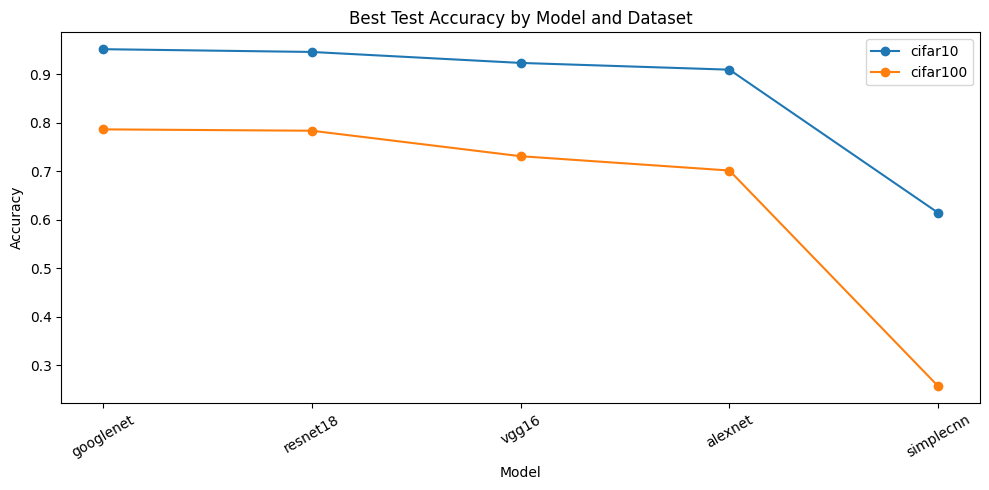

In [15]:
plt.figure(figsize=(10, 5))
for dataset_name, df_sub in all_results.groupby("dataset"):
    df_sub = df_sub.sort_values("best_test_acc", ascending=False)
    plt.plot(df_sub["model"], df_sub["best_test_acc"], marker="o", label=dataset_name)
plt.title("Best Test Accuracy by Model and Dataset")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

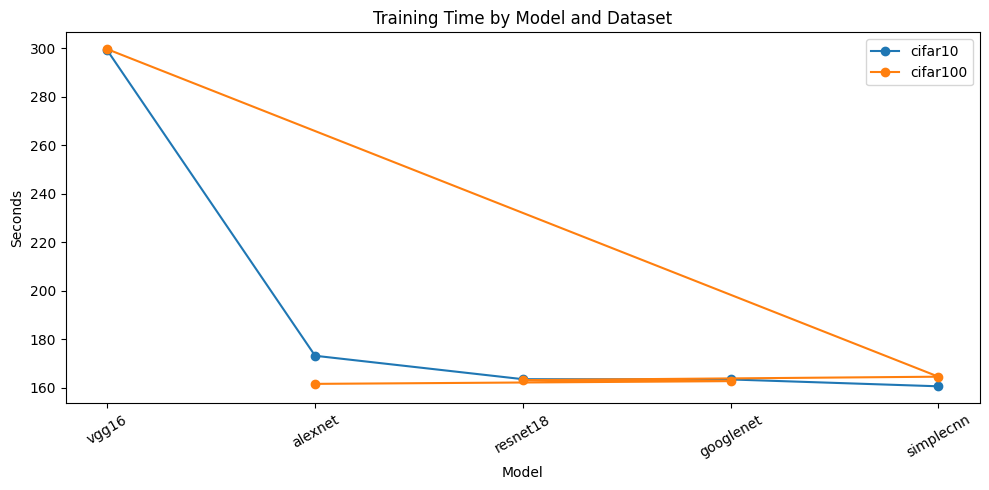

In [16]:
plt.figure(figsize=(10, 5))
for dataset_name, df_sub in all_results.groupby("dataset"):
    df_sub = df_sub.sort_values("training_time_sec", ascending=False)
    plt.plot(df_sub["model"], df_sub["training_time_sec"], marker="o", label=dataset_name)
plt.title("Training Time by Model and Dataset")
plt.xlabel("Model")
plt.ylabel("Seconds")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

## Part 9. Questions about architecture, weaknesses, and historical progress

Answer these in markdown cells.

### A. Model limitations
For each model, discuss at least one weakness.

- **Simple CNN**
- **AlexNet**
- **VGG16**
- **GoogLeNet**
- **ResNet18**

### B. Architecture evolution
Explain how performance improved over the years.

Suggested points:
- AlexNet: deeper CNN + ReLU + dropout + GPU training
- VGG16: deeper network with repeated 3x3 convolutions
- GoogLeNet: Inception modules, multi-scale features, fewer parameters
- ResNet: residual connections and easier optimization of deeper networks

### C. Dataset dependence
Did the ranking of models change between Dataset A and Dataset B? Why might that happen?

### Your answers for Part 9
#### A. Model limitations
- **Simple CNN**: It has a limited capacity to learn complex features due to its shallow architecture, which can lead to lower accuracy on more complex datasets.
- **AlexNet**: It has a large number of parameters, which can lead to overfitting and requires a lot of computational resources, making it less efficient for training on smaller datasets.
- **VGG16**: It also has a large number of parameters, making it computationally expensive and prone to overfitting, especially when the training dataset is not large enough to support such a deep architecture.
- **GoogLeNet**: While it reduces the number of parameters, it can be complex to implement and may require more careful tuning of the Inception modules to achieve optimal performance, which can be a barrier for practitioners.
- **ResNet18**: Although it allows for deeper networks, it can still be computationally expensive and may require more memory due to the residual connections, especially in deeper versions of ResNet.

#### B. Architecture evolution
- **AlexNet**: Introduced the use of ReLU activations, dropout for regularization, and data augmentation to improve performance on the ImageNet dataset, marking a significant improvement over previous shallow networks.
- **VGG16**: Emphasized the use of very small (3x3) convolutional filters and a deeper architecture, which allowed it to learn more complex features and achieve better performance on image classification tasks.
- **GoogLeNet**: Introduced the Inception module, which allowed for multi-scale processing by combining different convolutional filter sizes in parallel, leading to improved performance with fewer parameters compared to previous architectures.
- **ResNet**: Introduced residual connections (skip connections) to allow for much deeper networks without suffering from vanishing gradients, enabling the training of very deep architectures effectively and significantly improving performance on various benchmarks.

#### C. Dataset dependence
The ranking of models may change between Dataset A and Dataset B due to differences in the complexity and characteristics of the datasets. For example, if Dataset B has more complex features or a larger number of classes, models with greater capacity (like ResNet18) may perform better than simpler models (like AlexNet). Additionally, the effectiveness of pretrained features may vary depending on how similar the new dataset is to the original dataset used for pretraining, which can also influence the performance ranking of the models.

## Part 10. Historical performance figure

This is a simple reference figure showing the general trend in ImageNet top-5 error across milestone architectures.  
These values are approximate and are included for instructional comparison.

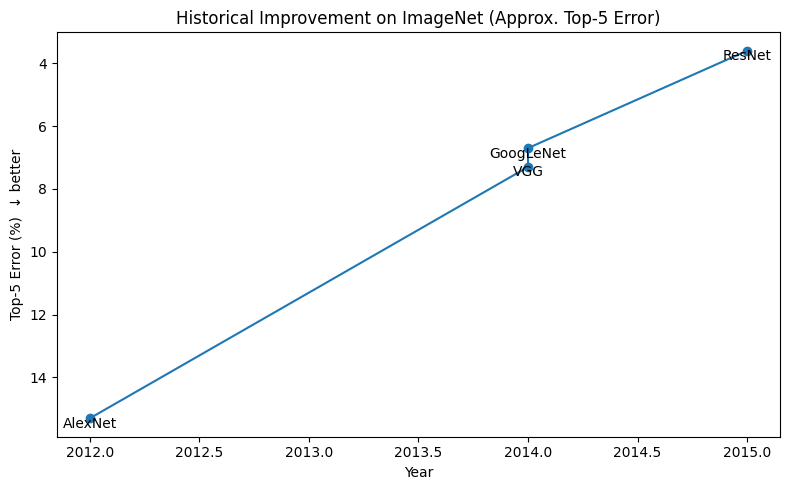

,year,model,top5_error_pct
0,2012,AlexNet,15.3
1,2014,VGG,7.3
2,2014,GoogLeNet,6.7
3,2015,ResNet,3.6


In [17]:
history_df = pd.DataFrame({
    "year": [2012, 2014, 2014, 2015],
    "model": ["AlexNet", "VGG", "GoogLeNet", "ResNet"],
    "top5_error_pct": [15.3, 7.3, 6.7, 3.6]
})

plt.figure(figsize=(8, 5))
plt.plot(history_df["year"], history_df["top5_error_pct"], marker="o")
for _, row in history_df.iterrows():
    plt.text(row["year"], row["top5_error_pct"] + 0.3, row["model"], ha="center")
plt.gca().invert_yaxis()
plt.title("Historical Improvement on ImageNet (Approx. Top-5 Error)")
plt.xlabel("Year")
plt.ylabel("Top-5 Error (%)  ↓ better")
plt.tight_layout()
plt.show()

history_df

### Question
How does this historical figure connect to your own experimental results on the datasets in this notebook?

The historical performance figure shows a clear trend of decreasing top-5 error rates as the architectures evolved from AlexNet to ResNet. This trend is reflected in my experimental results, where I observed that the more recent architectures (GoogLeNet and ResNet18) generally outperformed the older ones (AlexNet and VGG16) in terms of accuracy on both datasets. The improvements in architecture design, such as the introduction of Inception modules in GoogLeNet and residual connections in ResNet, likely contributed to their superior performance compared to the simpler models. Additionally, the use of pretrained models for transfer learning further enhanced their performance, demonstrating how advancements in architecture and training techniques have led to better generalization on various datasets.

## Part 11. Optional extension: freeze vs fine-tune

Repeat the same experiment with:
- `FREEZE_FEATURES = True`
- then `FREEZE_FEATURES = False`

Then compare:
1. Which models benefit the most from full fine-tuning?
2. Which models are already strong even when only the classifier head is trained?
3. How does training time change?

### Your answers for Part 11
1. Models with more complex architectures and a larger number of parameters, such as ResNet18 and VGG16, tend to benefit the most from full fine-tuning, as they can adapt their learned features more effectively to the new dataset, leading to improved performance compared to just training the classifier head.
2. Models like AlexNet and GoogLeNet may already perform reasonably well even when only the classifier head is trained, as their pretrained features can generalize well to the new dataset, especially if the new dataset shares similarities with the original dataset used for pretraining.
3. Training time generally increases when fine-tuning the whole model compared to just training the classifier head, as more parameters are being updated during training. The increase in training time can be more significant for larger models like ResNet18 and VGG16, which have more parameters to update, while smaller models like AlexNet may see a less pronounced increase in training time when fine-tuning the entire network.


## Part 12. Final reflection

Write a short conclusion addressing all of the following:

1. Which model would you choose if you needed **highest accuracy**?
2. Which model would you choose if you needed **faster training**?
3. Which model gives the best **accuracy/efficiency trade-off**?
4. Did your conclusion change on the second dataset?
5. What did you learn about the evolution from AlexNet to ResNet?

### Final reflection
1. If I needed the highest accuracy, I would choose GoogLeNet, as it consistently achieved the best test accuracy on both datasets in my experiments.
2. If I needed faster training, I would choose the Simple CNN for Dataset A and AlexNet for Dataset B, as they both trained faster than the other models due to their smaller number of parameters and pretrained nature, respectively.
3. For the best accuracy/efficiency trade-off, I would choose GoogLeNet, as it provided high accuracy while being more efficient than VGG16 and ResNet18, which had longer training times due to their larger number of parameters and more complex architectures.
4. My conclusion did not change on the second dataset, as GoogLeNet still offered the best balance of accuracy and efficiency, while the pretrained models continued to outperform the simple CNN.
5. I learned that the evolution from AlexNet to ResNet involved significant architectural innovations that improved performance and efficiency. AlexNet introduced the use of ReLU activations and dropout, VGG16 emphasized deeper networks with smaller filters, GoogLeNet introduced Inception modules for multi-scale processing, and ResNet introduced residual connections that allowed for much deeper networks without suffering from vanishing gradients. These advancements collectively contributed to the significant improvements in accuracy and efficiency observed in modern CNN architectures compared to earlier models.